In [6]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.metrics import mean_squared_error,r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor


In [7]:
df = pd.read_csv('data/StudentsPerformance.csv')

In [8]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [10]:
X = df.drop(columns=['math score'],axis=1)

In [11]:
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [16]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race/ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test preparation course'].unique())

Categories in 'gender' variable:      ['female' 'male']
Categories in 'race_ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:      ['standard' 'free/reduced']
Categories in 'test preparation course' variable:      ['none' 'completed']


In [18]:
y = df['math score']

In [24]:
##Create a column Transformer with 3 types of transformer
num_featuress=X.select_dtypes(exclude="object").columns.tolist()
cat_featuress=X.select_dtypes(include="object").columns.tolist()

In [25]:
num_featuress

['reading score', 'writing score']

In [26]:
cat_featuress

['gender',
 'race/ethnicity',
 'parental level of education',
 'lunch',
 'test preparation course']

In [29]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer=StandardScaler()
oh_transformer=OneHotEncoder()

preprocessor=ColumnTransformer(
    [
        ("OnehotEncoder",oh_transformer,cat_featuress),
        ("StandardScaler",numeric_transformer,num_featuress)
    ]
)

In [30]:
X=preprocessor.fit_transform(X)

In [31]:
X.shape

(1000, 19)

In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true, predicted)
    
    return mae, rmse, r2_square   # ✔️ only 3 values

In [42]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for name, model in models.items():   # ✔️ clean loop

    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluation
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(name)
    model_list.append(name)

    print('Model performance for Training set')
    print(f"- RMSE: {model_train_rmse:.4f}")
    print(f"- MAE: {model_train_mae:.4f}")
    print(f"- R2 Score: {model_train_r2:.4f}")

    print('----------------------------------')

    print('Model performance for Test set')
    print(f"- RMSE: {model_test_rmse:.4f}")
    print(f"- MAE: {model_test_mae:.4f}")
    print(f"- R2 Score: {model_test_r2:.4f}")

    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- RMSE: 5.3272
- MAE: 4.2784
- R2 Score: 0.8741
----------------------------------
Model performance for Test set
- RMSE: 5.4108
- MAE: 4.2279
- R2 Score: 0.8797


Lasso
Model performance for Training set
- RMSE: 6.5938
- MAE: 5.2063
- R2 Score: 0.8071
----------------------------------
Model performance for Test set
- RMSE: 6.5197
- MAE: 5.1579
- R2 Score: 0.8253


Ridge
Model performance for Training set
- RMSE: 5.3233
- MAE: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- RMSE: 5.3904
- MAE: 4.2111
- R2 Score: 0.8806


K-Neighbors Regressor
Model performance for Training set
- RMSE: 5.7122
- MAE: 4.5187
- R2 Score: 0.8553
----------------------------------
Model performance for Test set
- RMSE: 7.2516
- MAE: 5.6160
- R2 Score: 0.7839


Decision Tree
Model performance for Training set
- RMSE: 0.2795
- MAE: 0.0187
- R2 Score: 0.9997
----------------------------------
Model performance fo

c:\Users\ojass\OneDrive\Desktop\MLProjE2E\MLCE2E\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\ojass\OneDrive\Desktop\MLProjE2E\MLCE2E\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\ojass\OneDrive\Desktop\MLProjE2E\MLCE2E\lib\subprocess.py", line 489, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\ojass\OneDrive\Desktop\MLProjE2E\MLCE2E\lib\subprocess.py", line 854, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\ojass\OneDrive\Desktop\MLProjE2E\MLCE2E\lib\subprocess.py", line 1307, in _exe

Random Forest Regressor
Model performance for Training set
- RMSE: 2.2763
- MAE: 1.8193
- R2 Score: 0.9770
----------------------------------
Model performance for Test set
- RMSE: 6.0287
- MAE: 4.6637
- R2 Score: 0.8506


XGBRegressor
Model performance for Training set
- RMSE: 1.0073
- MAE: 0.6875
- R2 Score: 0.9955
----------------------------------
Model performance for Test set
- RMSE: 6.4733
- MAE: 5.0577
- R2 Score: 0.8278


CatBoosting Regressor
Model performance for Training set
- RMSE: 3.0427
- MAE: 2.4054
- R2 Score: 0.9589
----------------------------------
Model performance for Test set
- RMSE: 6.0086
- MAE: 4.6125
- R2 Score: 0.8516


AdaBoost Regressor
Model performance for Training set
- RMSE: 5.7782
- MAE: 4.7098
- R2 Score: 0.8519
----------------------------------
Model performance for Test set
- RMSE: 6.0704
- MAE: 4.7322
- R2 Score: 0.8486




In [43]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,Linear Regression,0.879689
7,CatBoosting Regressor,0.851632
5,Random Forest Regressor,0.850641
8,AdaBoost Regressor,0.848568
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbors Regressor,0.783898
4,Decision Tree,0.757642


In [44]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 87.97


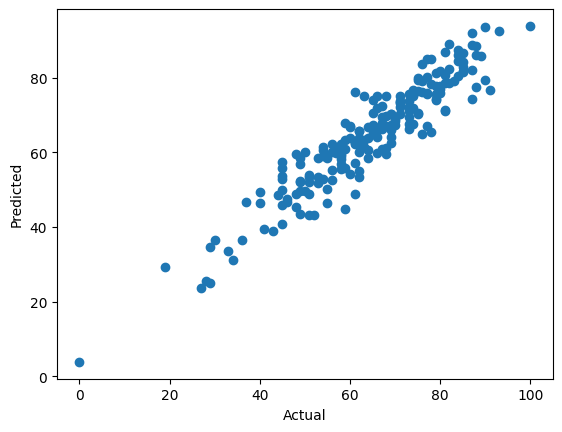

In [45]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

In [46]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.734375,14.265625
737,53,58.593750,-5.593750
740,80,76.843750,3.156250
660,74,76.750000,-2.750000
411,84,87.500000,-3.500000
...,...,...,...
408,52,43.156250,8.843750
332,62,62.125000,-0.125000
208,74,67.578125,6.421875
613,65,67.343750,-2.343750
